In [8]:
import pandas as pd

# Read whole file as plain text
with open("daily_HKO_RF_ALL.csv", "r", errors="ignore") as f:
    lines = f.read().splitlines()

# Print first few lines to inspect
for i, line in enumerate(lines[:10]):
    print(i, line)

0 ﻿日總雨量(毫米) - 天文台
1 Daily Total Rainfall (mm) at the Hong Kong Observatory
2 年/Year,月/Month,日/Day,數值/Value,數據完整性/data Completeness
3 1884,3,1,0.0,C
4 1884,3,2,0.0,C
5 1884,3,3,0.0,C
6 1884,3,4,0.0,C
7 1884,3,5,0.0,C
8 1884,3,6,0.0,C
9 1884,3,7,50.6,C


In [9]:
import pandas as pd

with open("daily_HKO_RF_ALL.csv", "r", errors="ignore") as f:
    lines = f.read().splitlines()

header = lines[2].split(",")
data_rows = [line.split(",") for line in lines[3:]]

df = pd.DataFrame(data_rows, columns=header)

df.head(), df.columns, df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49313 entries, 0 to 49312
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   年/Year                   49313 non-null  object
 1   月/Month                  49308 non-null  object
 2   日/Day                    49308 non-null  object
 3   數值/Value                 49308 non-null  object
 4   數據完整性/data Completeness  49308 non-null  object
dtypes: object(5)
memory usage: 1.9+ MB


(  年/Year 月/Month 日/Day 數值/Value 數據完整性/data Completeness
 0   1884       3     1      0.0                       C
 1   1884       3     2      0.0                       C
 2   1884       3     3      0.0                       C
 3   1884       3     4      0.0                       C
 4   1884       3     5      0.0                       C,
 Index(['年/Year', '月/Month', '日/Day', '數值/Value', '數據完整性/data Completeness'], dtype='object'),
 None)

In [10]:
df.columns = ["year", "month", "day", "rain_mm", "completeness"]

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["month"] = pd.to_numeric(df["month"], errors="coerce")
df["day"] = pd.to_numeric(df["day"], errors="coerce")
df["rain_mm"] = pd.to_numeric(df["rain_mm"], errors="coerce")

df = df.dropna(subset=["year", "month", "day", "rain_mm"]).copy()

df["date"] = pd.to_datetime(df[["year", "month", "day"]])

df.head(), df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42403 entries, 0 to 49307
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   year          42403 non-null  float64       
 1   month         42403 non-null  float64       
 2   day           42403 non-null  float64       
 3   rain_mm       42403 non-null  float64       
 4   completeness  42403 non-null  object        
 5   date          42403 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 2.3+ MB


(     year  month  day  rain_mm completeness       date
 0  1884.0    3.0  1.0      0.0            C 1884-03-01
 1  1884.0    3.0  2.0      0.0            C 1884-03-02
 2  1884.0    3.0  3.0      0.0            C 1884-03-03
 3  1884.0    3.0  4.0      0.0            C 1884-03-04
 4  1884.0    3.0  5.0      0.0            C 1884-03-05,
 None)

Plot 1 : monthly average rainfall

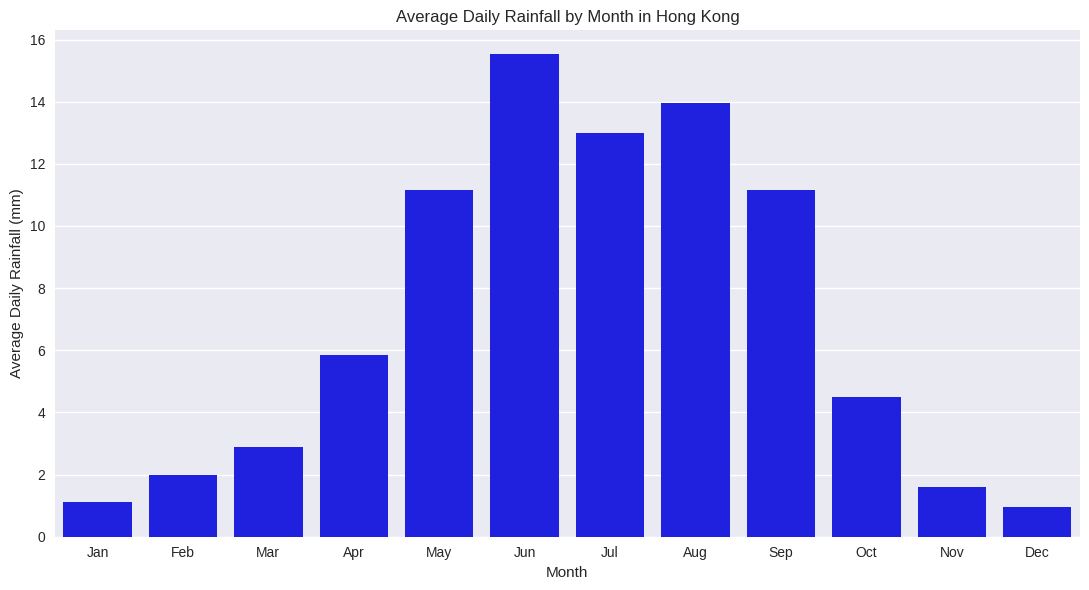

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("deep")

monthly_avg = df.groupby("month")["rain_mm"].mean().reset_index()

plt.figure(figsize=(11,6))
sns.barplot(data=monthly_avg, x="month", y="rain_mm", color="blue")
plt.title("Average Daily Rainfall by Month in Hong Kong")
plt.xlabel("Month")
plt.ylabel("Average Daily Rainfall (mm)")
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
plt.xticks(ticks=range(12), labels=month_labels)
plt.tight_layout()
plt.savefig("monthly_rainfall.png", dpi=200, bbox_inches="tight")
plt.show()

Plot 2 : annual total rainfall

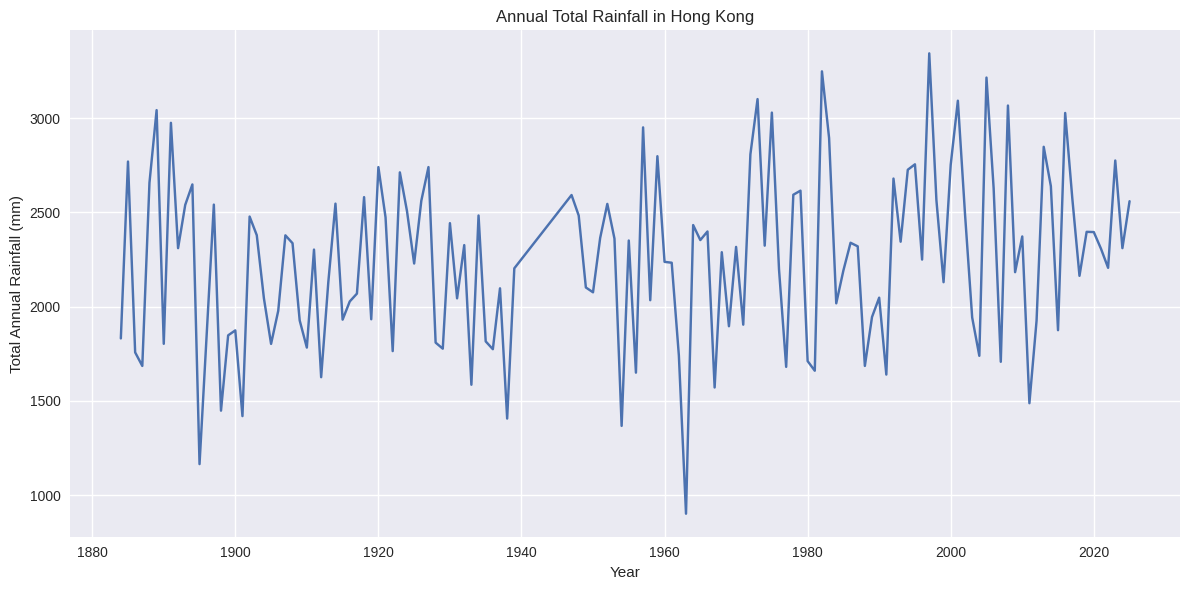

In [15]:
annual_total_complete = df_complete.groupby("year")["rain_mm"].sum().reset_index()

annual_total_complete = annual_total_complete[annual_total_complete["rain_mm"] > 500]

plt.figure(figsize=(11,6))
sns.lineplot(data=annual_total_complete, x="year", y="rain_mm")
plt.title("Annual Total Rainfall in Hong Kong")
plt.xlabel("Year")
plt.ylabel("Total Annual Rainfall (mm)")
plt.tight_layout()
plt.savefig("annual_rainfall_final.png", dpi=200, bbox_inches="tight")
plt.show()

Plot 3 : monthly distribution

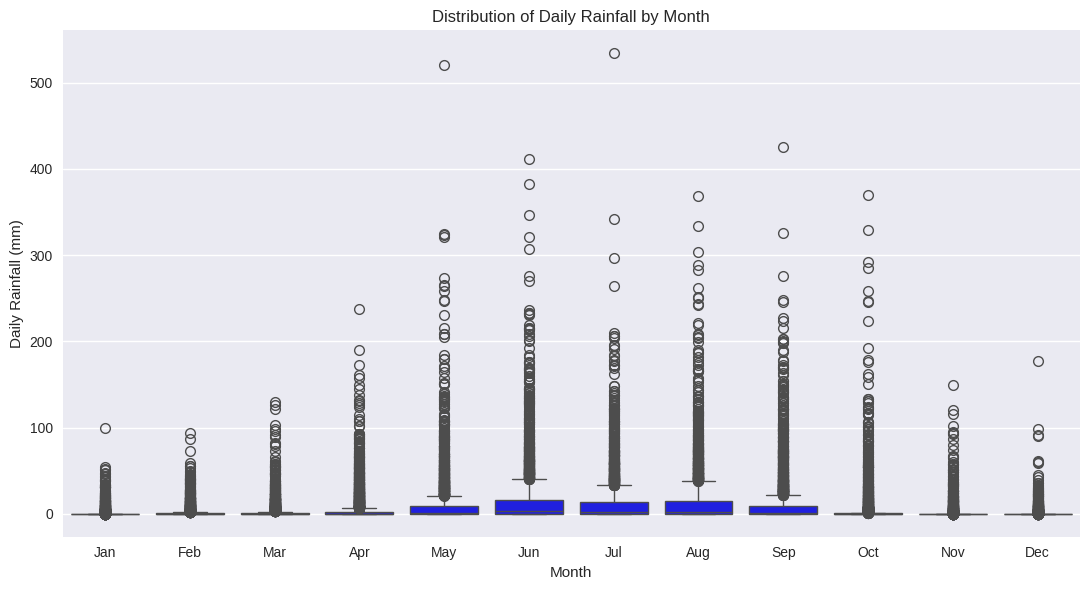

In [19]:
plt.figure(figsize=(11,6))
sns.boxplot(data=df, x="month", y="rain_mm", color="blue")
plt.title("Distribution of Daily Rainfall by Month")
plt.xlabel("Month")
plt.ylabel("Daily Rainfall (mm)")
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
plt.xticks(ticks=range(12), labels=month_labels)
plt.tight_layout()
plt.savefig("seasonality_boxplot.png", dpi=200, bbox_inches="tight")
plt.show()